Prototype Goal:  After running GraphCast with a specific ERA5 source input file (i.e., source-era5_date-2022-01-01_res-1.0_levels-13_steps-01), modify this input with observational values (i.e., e5303_m21c_jan18.diag_conv_t_ges.20220101_00z.nc4) for a specific variable (i.e., temperature) at the same time (i.e., 220101_00z) and pressure value (i.e., 850 mb) across levels. Rerun GraphCast and compare results.

Workflow (GI=Graphcast Initial Source file, OB=Obs_*_ges):  
1. Use scipy.interpolate.griddata to create gridded data from scattered Observation points (note that there may be multiple Observation values at each Pressure level for each variable) 
2. As per conversation with Amal & Mark, 
3.	For each Pressure level in GI
    * Aggregate OB values between +/-10 of GI level 
    * For example, where GI=850, get all OB value between 840 and 860
    * Average these OB values
4.  Replace the corresponding GI value with this average
5.	Save results as new NetCDF GI file 
6.	Run GraphCast prediction with new GI file
7.	Compare prediction results with results from original GI file


ToDo:  
1. Add support for multiple variables
2. Enhance QA
3. Add visualization for scattered and gridded values
4. Containerize workflow functionality
5. Make inputs configurable (e.g., variable, pressure level(s) of interest, time, etc.)

Notes from Amal/Mark discussion: 
1. The 'Observation" column in the OB file contains the raw variable values
2. Kx index needs to be involved, but not for 1st prototype
3.	Use range of +/- 10 when mapping OBS pressure to GI.  So, if GI is 850, take OBS 840 to 860
4.	Conventional (u,v,q,t,s) variables are more important than non-conventional
5.  Radiosonds have a range of data because they collect data in a moving column
6.	ERA5/GI is a subset of pressure levels in OBS (13 vs. > 13)
7.	Map OBS temperature to 1D Temperature in GI, not 2TM
8.	Override existing values in GI with average range, not all values between levels
9.	The landmask variable [1,0] indicates whether cell is over land or not (not used in prototype)
10.	Iterate with one variable replacement at a time staring with Pressure = 850
11.	Time [-3..3] delta from Xz (not used for prototype because it will be in 6hr batches like GI)

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import xarray as xr

from scipy.interpolate import griddata
import matplotlib.pyplot as plt # Optional: for visualization

Examine comparable OB and GI files

In [2]:
!ncdump -h /discover/nobackup/projects/gmao/merra21c/TSE_staging/e5303_m21c_jan18/archive/obs/Y2022/M01/D01/H00/e5303_m21c_jan18.diag_conv_t_ges.20220101_00z.nc4 

netcdf e5303_m21c_jan18.diag_conv_t_ges.20220101_00z {
dimensions:
	nobs = UNLIMITED ; // (137365 currently)
	Station_ID_maxstrlen = 8 ;
	Observation_Class_maxstrlen = 7 ;
	Bias_Correction_Terms_arr_dim = 3 ;
variables:
	char Station_ID(nobs, Station_ID_maxstrlen) ;
	char Observation_Class(nobs, Observation_Class_maxstrlen) ;
	int Observation_Type(nobs) ;
	int Observation_Subtype(nobs) ;
	float Latitude(nobs) ;
	float Longitude(nobs) ;
	float Station_Elevation(nobs) ;
	float Pressure(nobs) ;
	float Height(nobs) ;
	float Time(nobs) ;
	float LaunchTime(nobs) ;
	float Prep_QC_Mark(nobs) ;
	float Setup_QC_Mark(nobs) ;
	float Prep_Use_Flag(nobs) ;
	float Analysis_Use_Flag(nobs) ;
	float Nonlinear_QC_Rel_Wgt(nobs) ;
	float Errinv_Input(nobs) ;
	float Errinv_Adjust(nobs) ;
	float Errinv_Final(nobs) ;
	float Error_Input(nobs) ;
	float Error_Adjust(nobs) ;
	float Observation(nobs) ;
	float Obs_Minus_Forecast_adjusted(nobs) ;
	float Obs_Minus_Forecast_unadjusted(nobs) ;
	float Forecast_unadjuste

In [3]:
!ncdump -h  /discover/nobackup/projects/QEFM/qefm-core/qefm/models/src/FMGraphCast/../../checkpoints/graphcast/source-era5_date-2022-01-01_res-1.0_levels-13_steps-01.nc

netcdf source-era5_date-2022-01-01_res-1.0_levels-13_steps-01 {
dimensions:
	batch = 1 ;
	time = 3 ;
	lat = 181 ;
	lon = 360 ;
	level = 13 ;
variables:
	float lon(lon) ;
		lon:long_name = "longitude" ;
		lon:units = "degrees_east" ;
		lon:_FillValue = NaNf ;
	float geopotential_at_surface(lat, lon) ;
		geopotential_at_surface:_FillValue = NaNf ;
	float land_sea_mask(lat, lon) ;
		land_sea_mask:_FillValue = NaNf ;
	float lat(lat) ;
		lat:long_name = "latitude" ;
		lat:units = "degrees_north" ;
		lat:_FillValue = NaNf ;
	int level(level) ;
	int time(time) ;
		time:units = "hours" ;
	float \2m_temperature(batch, time, lat, lon) ;
		\2m_temperature:coordinates = "datetime" ;
		\2m_temperature:_FillValue = NaNf ;
	float mean_sea_level_pressure(batch, time, lat, lon) ;
		mean_sea_level_pressure:coordinates = "datetime" ;
		mean_sea_level_pressure:_FillValue = NaNf ;
	float \10m_v_component_of_wind(batch, time, lat, lon) ;
		\10m_v_component_of_wind:coordinates = "datetime" ;
		\10m_v_compone

Define function to convert OB to modified GI

In [4]:
    import xarray as xr
    import numpy as np
    from scipy.interpolate import griddata
    import pandas as pd
    @staticmethod

    def obs_to_gridded_netcdf2(input_file, output_file, var_name, grid_resolution=0.25, method='linear'):
        """
        Converts an observation-based (scattered points) NetCDF file to a gridded NetCDF file.

        Args:
            input_file (str): Path to the input NetCDF file.
            output_file (str): Path to save the output gridded NetCDF file.
            var_name (str): The name of the variable to interpolate (e.g., 'temperature').
            grid_resolution (float): The desired resolution of the new grid in degrees.
            method (str): Interpolation method ('linear', 'nearest', 'cubic').
        """
        print("obs_to_gridded_netcdf2(" + str(input_file) + " " + str(output_file) + 
              " " + str(var_name) + " " + str(grid_resolution) + " " + str(method) + ")")
        # 1. Load the input data using xarray
        ds_obs = xr.open_dataset(input_file)
        
        # Extract coordinates and the variable data
        # Assuming the input NetCDF has 'lat', 'lon', and the target 'var_name' as dimensions or variables
        # The dimensions in the observation file might be 'site_id' or 'point'
        try:
            lats_obs = ds_obs['Latitude'].values
            lons_obs = ds_obs['Longitude'].values
            level_values_obs = ds_obs['Pressure'].values
            # level_values_obs = (ds_obs['Pressure'].values).astype('int16')
            # print(level_values_obs, level_values_obs.flatten())
            # data_int = ds_obs['Pressure'].astype('int16')
            # print(data_int)
            values_obs = ds_obs[var_name].values
        except KeyError as e:
            print(f"Error: Missing expected coordinate or variable name: {e}")
            return

        # Prepare input points for scipy.interpolate.griddata
        # Flatten coordinates and values if they are not already 1D
        points = np.column_stack((lons_obs.flatten(), lats_obs.flatten()))
        values = values_obs.flatten()

        # 2. Define the target regular grid
        # For now, hard-code min/max from GraphCast init state (GI)
        lon_min, lon_max = 0.0, 359.75
        lat_min, lat_max = -90.0, 90.0
        # Determine the extent of the original data to create a reasonable grid
        # lon_min, lon_max = lons_obs.min(), lons_obs.max()
        # lat_min, lat_max = lats_obs.min(), lats_obs.max()

        # Create the new regular grid coordinates
        new_lons = np.arange(lon_min, lon_max + grid_resolution, grid_resolution)
        new_lats = np.arange(lat_min, lat_max + grid_resolution, grid_resolution)
        X_new, Y_new = np.meshgrid(new_lons, new_lats)

        # 3. Perform the interpolation using scipy.interpolate.griddata
        print(f"Starting interpolation using method: '{method}'...")
        gridded_values = griddata(points, values, (X_new, Y_new), method=method)
        print("Interpolation complete.")

        # constant = 1000000
        # numpy_gridded_values = numpy_gridded_values * constant
        numpy_gridded_values = np.array(gridded_values)
        gridded_values = numpy_gridded_values.tolist()

        # 4. Create a new xarray Dataset for the gridded data
        # Add coordinates as 1D arrays for a standard gridded NetCDF format
        # ds_gridded = xr.Dataset(
        #     {
        #         var_name: (("lat", "lon"), gridded_values),
        #         'Pressure': (("lat", "lon"), level_values_obs),
        #     },
        #     coords={
        #         "lon": new_lons,
        #         "lat": new_lats,
        #         "level": level_values_obs,
        #     }
        # )
        ds_gridded = xr.Dataset(
            {
                var_name: (("lat", "lon"), gridded_values),
            },
            coords={
                "lon": new_lons,
                "lat": new_lats,
                "level": level_values_obs,
            }
        )

        # Copy attributes from the original variable to the new one (optional but recommended for CF conventions)
        ds_gridded[var_name].attrs = ds_obs[var_name].attrs
        ds_gridded.attrs = ds_obs.attrs
        
        # 5. Save the new dataset to a NetCDF file
        ds_gridded.to_netcdf(output_file)
        print(f"Successfully saved gridded data to {output_file}")
        return ds_gridded


Call Function to convert OB to modified GI, passing in OB path and variable to interrogate.  
* Note that 'Observation' column in OB contains raw values for variable of interest.
* For now, other columns (e.g., Error_Adjust) aren't used, but eventually they will be for fine tuning.

In [5]:
# Convert observation point data to gridded data using scipy.interpolate 
ds_OB_gridded = obs_to_gridded_netcdf2(
    "/discover/nobackup/projects/QEFM/qefm-core/data/NSE/input/e5303_m21c_jan18.diag_conv_t_ges.20210101_00z.nc4",
    "/discover/nobackup/projects/QEFM/qefm-core/data/NSE/output/e5303_m21c_jan18.diag_conv_t_ges.20210101_00z_gridded_levels.nc4",
    "Observation"
)

obs_to_gridded_netcdf2(/discover/nobackup/projects/QEFM/qefm-core/data/NSE/input/e5303_m21c_jan18.diag_conv_t_ges.20210101_00z.nc4 /discover/nobackup/projects/QEFM/qefm-core/data/NSE/output/e5303_m21c_jan18.diag_conv_t_ges.20210101_00z_gridded_levels.nc4 Observation 0.25 linear)
Starting interpolation using method: 'linear'...
Interpolation complete.
Successfully saved gridded data to /discover/nobackup/projects/QEFM/qefm-core/data/NSE/output/e5303_m21c_jan18.diag_conv_t_ges.20210101_00z_gridded_levels.nc4


In [6]:
ds_grid=ds_OB_gridded
ds_grid

<xarray.Dataset> Size: 9MB
Dimensions:      (lat: 721, lon: 1440, level: 112633)
Coordinates:
  * lon          (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * level        (level) float32 451kB 6.78e+04 3.28e+04 ... 1.008e+05 1.007e+05
Data variables:
    Observation  (lat, lon) float64 8MB 243.4 243.4 243.4 243.4 ... nan nan nan
Attributes:
    Number_of_Predictors:  3
    date_time:             2021010100
    Number_of_state_vars:  867

In [7]:
ds = ds_grid

Specify pressure range +/- 10 from pressure level of interest

In [8]:
level_of_interest = 850
lower_bound = level_of_interest - 10
upper_bound = level_of_interest + 10

Determine how many OB values exist in pressure range

In [9]:
condition_mask = (ds['level'] >= lower_bound) & (ds['level'] <= upper_bound)
print(condition_mask)
indices = np.where(condition_mask.values)
print(indices[0].size)

<xarray.DataArray 'level' (level: 112633)> Size: 113kB
array([False, False, False, ..., False, False, False])
Coordinates:
  * level    (level) float32 451kB 6.78e+04 3.28e+04 ... 1.008e+05 1.007e+05
42


Filter OB values by pressure range and identify corresponding lat/lons

In [10]:
level_mask = (ds.level >= lower_bound) & (ds.level <= upper_bound)
selected_levels = ds.where(level_mask, drop=True)
#print(selected_levels.size)

# Get corresponding lat/lon coordinates
lats = selected_levels.lat.values
lons = selected_levels.lon.values
print(lats.size,lons.size)
print(lats[0],lons[0])
print(lats[720],lons[1439])
print(ds.level.values)

721 1440
-90.0 0.0
90.0 359.75
[ 67800.  32800.  31800. ... 100540. 100760. 100670.]


Calculate average Temperature value across pressure range (840-860]

In [11]:
obs_avg_temperature_at_level_850 = selected_levels['Observation'].mean()
print(selected_levels, selected_levels['Observation'].size)
print("The magic number for avg. temperature at level=850 [range = ", str(lower_bound), "-", str(upper_bound), "]: ", float(obs_avg_temperature_at_level_850));

<xarray.Dataset> Size: 349MB
Dimensions:      (lat: 721, lon: 1440, level: 42)
Coordinates:
  * lon          (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * level        (level) float32 168B 850.0 840.0 860.0 ... 860.0 860.0 840.0
Data variables:
    Observation  (lat, lon, level) float64 349MB 243.4 243.4 243.4 ... nan nan
Attributes:
    Number_of_Predictors:  3
    date_time:             2021010100
    Number_of_state_vars:  867 43606080
The magic number for avg. temperature at level=850 [range =  840 - 860 ]:  275.6564662919043


In [12]:
# 1. Load the input data using xarray
GI_file = "/discover/nobackup/projects/QEFM/qefm-core/data/NSE/input/graphcast/source-era5_date-2022-01-01_res-1.0_levels-13_steps-01.nc"
ds_GI = xr.open_dataset(GI_file)

# Extract coordinates and the variable data
# Assuming the input NetCDF has 'lat', 'lon', and the target 'var_name' as dimensions or variables
# The dimensions in the observation file might be 'site_id' or 'point'
try:
    batchs_GI = ds_GI['batch'].values
    lats_GI = ds_GI['lat'].values
    lons_GI = ds_GI['lon'].values
    levels_GI = ds_GI['level'].values
    times_GI = ds_GI['time'].values
    temperatures_GI = ds_GI['temperature'].values
except KeyError as e:
    print(f"Error: Missing expected coordinate or variable name: {e}")

In [13]:
print("Pressure levels = ", levels_GI)
initial_GI_avg = temperatures_GI.mean()
print("Original Global average Temperature = ", initial_GI_avg)
print("Time steps = ", times_GI)

Pressure levels =  [  50  100  150  200  250  300  400  500  600  700  850  925 1000]
Original Global average Temperature =  242.50656
Time steps =  [             0 21600000000000 43200000000000]


In [14]:
level_coord = 'level' 
mask = (ds_GI[level_coord] == 850)
print(mask)
ds_GI['temperature'].values[..., mask, :, :] = obs_avg_temperature_at_level_850
print("New Global average Temperature = ", ds_GI['temperature'].values.mean())
print("Change in Global average Temperature (GI - OB) = ", initial_GI_avg - ds_GI['temperature'].values.mean())

<xarray.DataArray 'level' (level: 13)> Size: 13B
array([False, False, False, False, False, False, False, False, False,
       False,  True, False, False])
Coordinates:
  * level    (level) int32 52B 50 100 150 200 250 300 ... 600 700 850 925 1000
New Global average Temperature =  242.65652
Change in Global average Temperature (GI - OB) =  -0.14996338


In [15]:
print("Avg. Temperature delta after overriding with OB:  ", initial_GI_avg - ds_GI['temperature'].values.mean())

Avg. Temperature delta after overriding with OB:   -0.14996338


In [16]:
import os
out_dir = "/discover/nobackup/projects/QEFM/qefm-core/data/NSE/output/graphcast"
#out_file_value = f"graphcast-prediction-{input_source}_date-{date_str}_res-{res}_levels-{levs}_freq-{cfreq}h_steps-{eval_steps}.nc"
out_file_value = "_source-era5_date-2022-01-01_res-1.0_levels-13_steps-01.nc"
out_file = os.path.join(out_dir, out_file_value)
ds_GI.to_netcdf(out_file)
# days=(6*eval_steps)/24
print("Saved obs-updated temps for lev=", str(level_of_interest), " : \n", out_file, "\n")

Saved obs-updated temps for lev= 850  : 
 /discover/nobackup/projects/QEFM/qefm-core/data/NSE/output/graphcast/_source-era5_date-2022-01-01_res-1.0_levels-13_steps-01.nc 



Quality Assurance

Verify updates to the Temperature variable in the output GI NetCDF4 file.  More occurences (many more) of the average Temperature values will be in the generated GI file in comparison to the original GI file.

In [17]:
!/usr/local/other/nco/5.1.7/bin/ncks -O -d level,10 -v temperature /discover/nobackup/projects/QEFM/qefm-core/qefm/models/src/FMGraphCast/../../checkpoints/graphcast/source-era5_date-2022-01-01_res-1.0_levels-13_steps-01.nc output.nc

In [18]:
!/usr/local/other/anaconda/GEOSpyD/24.3.0-0/2024-08-29/envs/py3.12/bin/ncdump -v temperature output.nc | grep 275.65 | wc -l

14


In [19]:
!/usr/local/other/nco/5.1.7/bin/ncks -O -d level,10 -v temperature /discover/nobackup/projects/QEFM/qefm-core/data/NSE/output/graphcast/_source-era5_date-2022-01-01_res-1.0_levels-13_steps-01.nc _output.nc

In [20]:
!/usr/local/other/anaconda/GEOSpyD/24.3.0-0/2024-08-29/envs/py3.12/bin/ncdump -v temperature _output.nc | grep 275.65 | wc -l

28236


Rerun GraphCast twice, pointing to each GI file (original and new one).  Compare Prediction results in output netcdf files.

1. Retrieve https://github.com/nasa-nccs-hpda/qefm-core/blob/main/qefm/models/src/FMGraphCast/fm_graphcast_nse.py
2. Set 'nse' to toggle between original and new GI file
3. Modify 'dataset_file' to point to the GI files
4. Modify 'out_file_value' = to specify full path to output Prediction file

Compare Prediction results in output netcdf files.

In [21]:
import xarray as xr
import matplotlib.pyplot as plt
import hvplot.xarray

# Define file paths
file1 = '/discover/nobackup/projects/QEFM/qefm-core/qefm/models/checkpoints/graphcast/pred-era5_date-2022-01-01_res-1.0_levels-13_steps-01.nc'
file2 = '/discover/nobackup/projects/QEFM/qefm-core/qefm/models/checkpoints/graphcast/_pred-era5_date-2022-01-01_res-1.0_levels-13_steps-01.nc'
file1_path = file1
file2_path = file2

# Open both datasets
ds1 = xr.open_dataset(file1_path)
ds2 = xr.open_dataset(file2_path)

# Choose a variable common to both files (replace 'your_variable_name' as needed)
variable_name = 'temperature'
#variable_name = 'geopotential'

if variable_name in ds1 and variable_name in ds2:
    # Calculate the difference: file2 - file1
    diff = ds2[variable_name] - ds1[variable_name]

    print(f"Difference statistics for variable '{variable_name}':")
    print(f"  Mean difference: {diff.mean().values}")
    print(f"  Max difference: {diff.max().values}")
    print(f"  Min difference: {diff.min().values}")
else:
    print(f"Variable '{variable_name}' not found in both files. Check variable names.")

difference=diff

Difference statistics for variable 'temperature':
  Mean difference: 0.16723603010177612
  Max difference: 34.22456359863281
  Min difference: -15.15020751953125


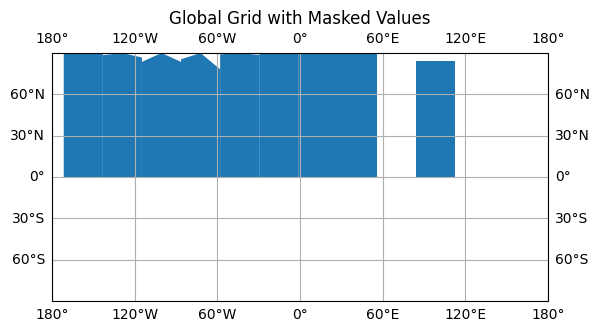

In [22]:
masked_data = selected_levels['Observation']
# Define a PlateCarree projection for a simple global map
import cartopy.crs as ccrs
projection = ccrs.PlateCarree()

# Create a figure and an axis with the specified projection
fig, ax = plt.subplots(subplot_kw={'projection': projection})

# Plot the masked data using xarray's plot function
# transform=ccrs.PlateCarree() is crucial if your data uses lat/lon coordinates
masked_data.plot(ax=ax, transform=ccrs.PlateCarree())

# Add map features for context
#ax.add_feature(cfeature.COASTLINE, linestyle=':')
#ax.add_feature(cfeature.BORDERS, linestyle=':')
#ax.add_feature(cfeature.LAND, color='lightgray') # Gray out the land area
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# Set the plot extent to be global
ax.set_global()

# Add a title
ax.set_title('Global Grid with Masked Values')

# Display the plot
plt.show()


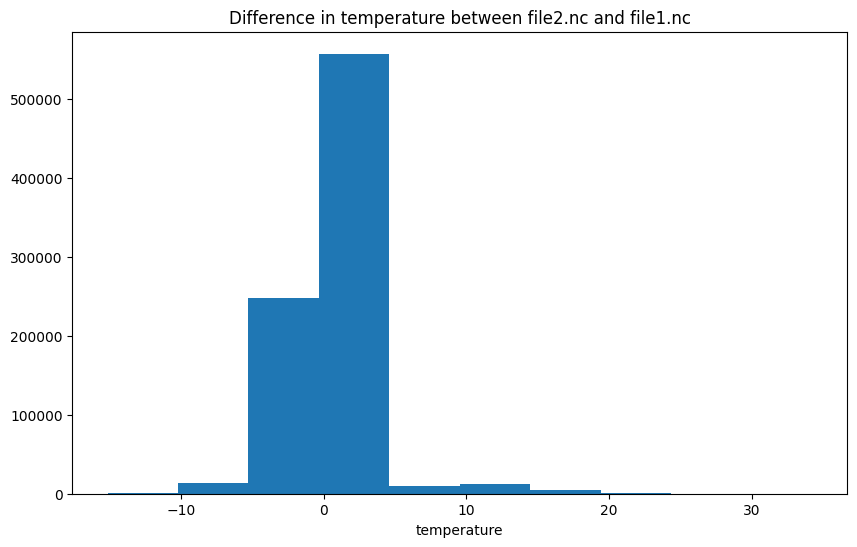

In [23]:
# Set up the plot
plt.figure(figsize=(10, 6))

# Plot the difference
# da.plot() makes quick visualization easy
#difference.plot(cmap='coolwarm', cbar_kwargs={'label': 'Difference Unit (e.g., K or C)'})
difference.plot()

# Add a title
plt.title(f'Difference in {variable_name} between file2.nc and file1.nc')

# Display the plot
plt.show()


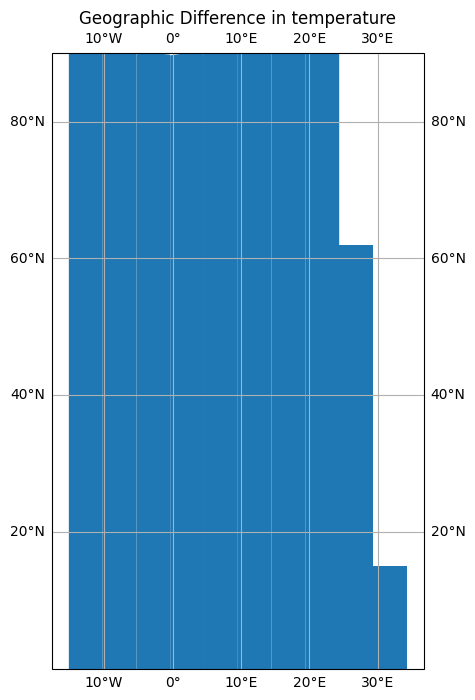

In [24]:
# Requires cartopy (pip install cartopy)
# Assuming 'longitude' and 'latitude' are the coordinate names
import cartopy.crs as ccrs
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Plot the difference on a map
difference.plot(ax=ax, transform=ccrs.PlateCarree()) 
# difference.plot(ax=ax, transform=ccrs.PlateCarree(), 
#                 vmin=-abs(difference.max()) if abs(difference.min()) < abs(difference.max()) else difference.min(),
#                 vmax=abs(difference.max()))
# # Plot the difference on a map
# difference.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='coolwarm',
#                 cbar_kwargs={'label': 'Difference Unit'},
#                 vmin=-abs(difference.max()) if abs(difference.min()) < abs(difference.max()) else difference.min(),
#                 vmax=abs(difference.max()))

# Add map features
#ax.coastlines()
ax.gridlines(draw_labels=True)
plt.title(f'Geographic Difference in {variable_name}')
plt.show()


Quick Static Plot (matplotlib through xarray): The xarray package has a built-in plot() method which makes quick visualization easy.

In [25]:
import hvplot

In [26]:
# Use .interactive() or .hvplot() for interactive visualization in Jupyter
diff.hvplot(title=f'Interactive Difference Plot for {variable_name}')


:NdOverlay   [Element]
   :Histogram   [temperature]   (temperature_count)

In [27]:
import cartopy.crs as ccrs
import matplotlib
from matplotlib import pyplot as plt
import xarray as xr

In [28]:
ds=ds_OB_gridded
ds

<xarray.Dataset> Size: 9MB
Dimensions:      (lat: 721, lon: 1440, level: 112633)
Coordinates:
  * lon          (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * level        (level) float32 451kB 6.78e+04 3.28e+04 ... 1.008e+05 1.007e+05
Data variables:
    Observation  (lat, lon) float64 8MB 243.4 243.4 243.4 243.4 ... nan nan nan
Attributes:
    Number_of_Predictors:  3
    date_time:             2021010100
    Number_of_state_vars:  867

In [29]:
file_path="/discover/nobackup/projects/QEFM/qefm-core/data/NSE/input/e5303_m21c_jan18.diag_conv_t_ges.20210101_00z.nc4"
ds = xr.open_dataset(file_path)

observation_values = ds["Observation"].values
lats = ds["Latitude"].values
lons = ds["Longitude"].values
times = ds["Time"].values

# --- FIX 2: Define a single dimension for the unstructured data ---
combined_data = xr.DataArray(
    data=observation_values,        # This is 1D data
    dims=['nobs'],             # Specify the single dimension name
    coords={                        # Attach 1D coordinates to that dimension
        'lat': (('nobs',), lats),
        'lon': (('nobs',), lons),
        'time': (('nobs',), times)
    },
    name='Observations'
)

print("Successfully combined 1D unstructured data.")
print(combined_data.dims) # Output: ('obs_point',)

Successfully combined 1D unstructured data.
('nobs',)


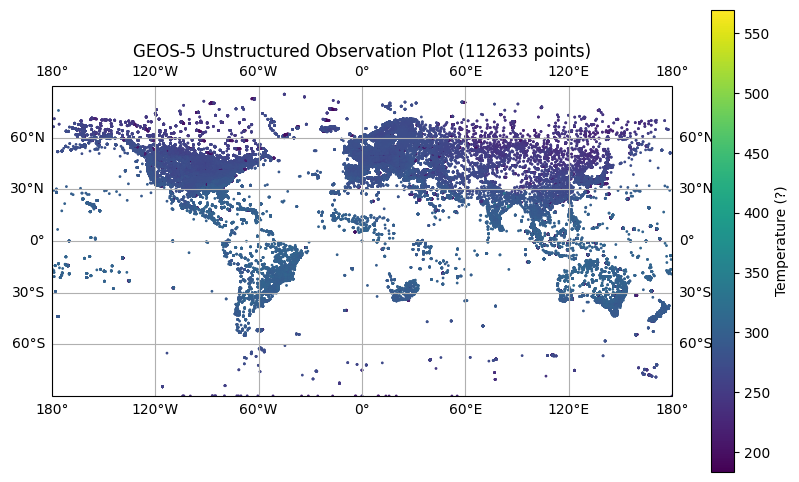

In [30]:
# Access the raw numpy array using .values
values = observation_values

# 2. Create the plot using matplotlib and cartopy for a map
plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
#ax.coastlines(resolution='50m')
ax.gridlines(draw_labels=True)

# 3. Use a SCATTER plot for 1D, unstructured data
# The 'c' argument provides the color mapping based on the observation value
scatter = ax.scatter(lons, lats, c=values, cmap='viridis', s=1, transform=ccrs.PlateCarree())

# Add a color bar
plt.colorbar(scatter, label=f'Temperature (?)', ax=ax)
#plt.colorbar(scatter, label=f'{combined_data.name} ({combined_data.units})', ax=ax)

plt.title(f'GEOS-5 Unstructured Observation Plot ({values.size} points)')
plt.show()

Dataset opened successfully:
<xarray.Dataset> Size: 22MB
Dimensions:                  (time: 1, batch: 1, lat: 181, lon: 360, level: 13)
Coordinates:
  * lon                      (lon) float32 1kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
  * lat                      (lat) float32 724B -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) int32 52B 50 100 150 200 ... 850 925 1000
  * time                     (time) timedelta64[ns] 8B 06:00:00
Dimensions without coordinates: batch
Data variables:
    10m_u_component_of_wind  (time, batch, lat, lon) float32 261kB ...
    10m_v_component_of_wind  (time, batch, lat, lon) float32 261kB ...
    2m_temperature           (time, batch, lat, lon) float32 261kB ...
    geopotential             (time, batch, level, lat, lon) float32 3MB ...
    mean_sea_level_pressure  (time, batch, lat, lon) float32 261kB ...
    specific_humidity        (time, batch, level, lat, lon) float32 3MB ...
    temperature              (time, batch, level, lat, l

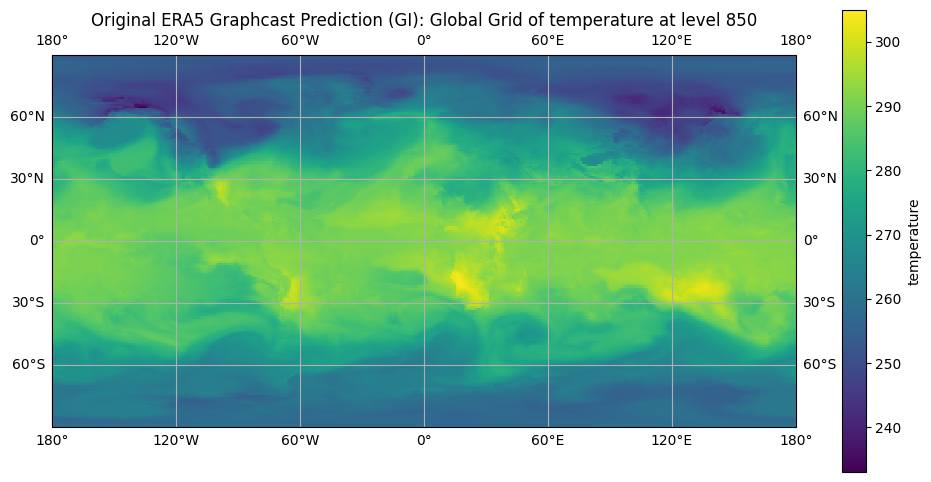

In [31]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# --- 1. Open the NetCDF file ---
# Replace 'path/to/your/file.nc' with the actual path to your NetCDF file
# xarray is inspired by pandas and provides a Pythonic interface to NetCDF files
file_path = '/discover/nobackup/projects/QEFM/qefm-core/qefm/models/checkpoints/graphcast/pred-era5_date-2022-01-01_res-1.0_levels-13_steps-01.nc'
try:
    ds = xr.open_dataset(file_path)
    print("Dataset opened successfully:")
    print(ds) # Printing the dataset gives a detailed overview of its components
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
    print("Please check the file path and name, or use a sample OPeNDAP URL instead.")
    # Example public OPeNDAP URL for global data (NAO global surface temperature):
    # file_path = 'www.ncei.noaa.gov'
    # ds = xr.open_dataset(file_path)

# --- 2. Prepare the data for plotting ---
# Identify the main variable you want to plot (e.g., 'temp', 'sst', 'precip')
# and the coordinate variables (latitude, longitude, time).
# You may need to inspect the output of print(ds) to find the correct names.
variable_name = 'temperature' # Example variable name
data_var = ds[variable_name]
GI_temperature_var = ds[variable_name]

# If your longitude data ranges from 0 to 360 degrees, it often needs to be shifted
# to -180 to 180 for better plotting on a global map using cartopy.
# if data_var.lon.max() > 180:
#     # Shift the longitude values
#     ds['lon'] = (ds['lon'] + 180) % 360 - 180
#     ds = ds.sortby('lon')
#     data_var = ds[variable_name]
#     print("Longitude shifted to -180 to 180 range.")

# Select a single time slice or depth level if the data is 3D or 4D
if 'level' in data_var.dims:
    # Select the first time step for simplicity
    plot_data = data_var.isel(level=10)
    plot_title = f'Original ERA5 Graphcast Prediction (GI): Global Grid of {variable_name} at level {plot_data.level.values}'
else:
# if 'time' in data_var.dims:
#     # Select the first time step for simplicity
#     plot_data = data_var.isel(time=0)
#     plot_title = f'Global Grid of {variable_name} at time {plot_data.time.values}'
# else:
    plot_data = data_var
    plot_title = f'Original ERA5 Graphcast Prediction: Global Grid of {variable_name}'

# --- 3. Plotting the global grid ---

# Set up the figure and a map projection (e.g., PlateCarree is good for global rectangular grids)
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Add coastlines and gridlines for context
#ax.add_feature(cfeature.COASTLINE, linestyle=':')
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
ax.set_global() # Ensure the map shows the whole globe

# Use xarray's built-in plot method, which intelligently uses matplotlib
# The transform argument tells cartopy that the data itself is in PlateCarree coordinates
#plot_data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='viridis', cbar_kwargs={'label': f'{variable_name} ({data_var.units if hasattr(data_var, "units") else "units"})'})
plot_data.plot(ax=ax, transform=ccrs.PlateCarree())

# Add the title and display the plot in the notebook
plt.title(plot_title)
plt.show()

Dataset opened successfully:


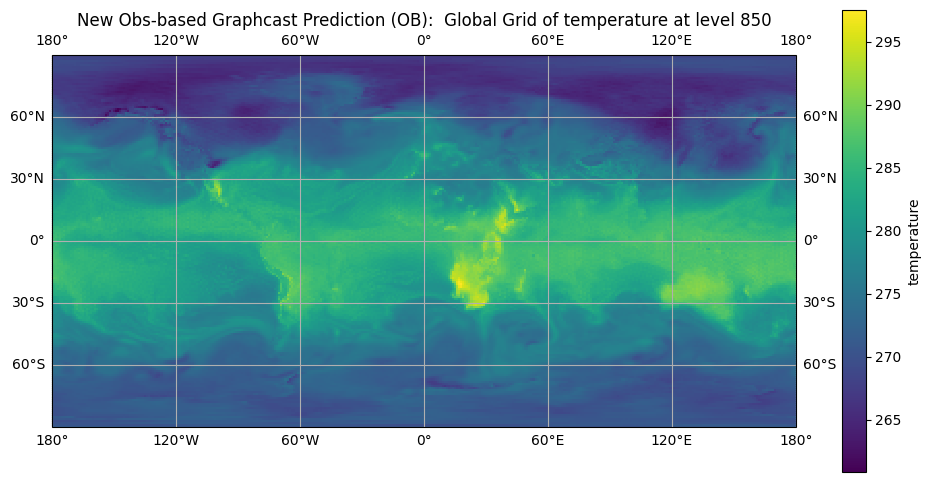

In [32]:
# --- 1. Open the NetCDF file ---
# Replace 'path/to/your/file.nc' with the actual path to your NetCDF file
# xarray is inspired by pandas and provides a Pythonic interface to NetCDF files
file_path = '/discover/nobackup/projects/QEFM/qefm-core/qefm/models/checkpoints/graphcast/_pred-era5_date-2022-01-01_res-1.0_levels-13_steps-01.nc'
#file_path = '/explore/nobackup/projects/ilab/projects/QEFM/qefm-core/qefm/models/checkpoints/graphcast/_pred-era5_date-2022-01-01_res-1.0_levels-13_steps-01.nc'
try:
    ds = xr.open_dataset(file_path)
    print("Dataset opened successfully:")
#    print(ds) # Printing the dataset gives a detailed overview of its components
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
    print("Please check the file path and name, or use a sample OPeNDAP URL instead.")
    # Example public OPeNDAP URL for global data (NAO global surface temperature):
    # file_path = 'www.ncei.noaa.gov'
    # ds = xr.open_dataset(file_path)

# --- 2. Prepare the data for plotting ---
# Identify the main variable you want to plot (e.g., 'temp', 'sst', 'precip')
# and the coordinate variables (latitude, longitude, time).
# You may need to inspect the output of print(ds) to find the correct names.
variable_name = 'temperature' # Example variable name
data_var = ds[variable_name]
OB_temperature_var = ds[variable_name]

# If your longitude data ranges from 0 to 360 degrees, it often needs to be shifted
# to -180 to 180 for better plotting on a global map using cartopy.
# if data_var.lon.max() > 180:
#     # Shift the longitude values
#     ds['lon'] = (ds['lon'] + 180) % 360 - 180
#     ds = ds.sortby('lon')
#     data_var = ds[variable_name]
#     print("Longitude shifted to -180 to 180 range.")
# Select a single time slice or depth level if the data is 3D or 4D
if 'level' in data_var.dims:
    # Select the first time step for simplicity
    plot_data = data_var.isel(level=10)
    plot_title = f'New Obs-based Graphcast Prediction (OB):  Global Grid of {variable_name} at level {plot_data.level.values}'
else:
# if 'time' in data_var.dims:
#     # Select the first time step for simplicity
#     plot_data = data_var.isel(time=0)
#     plot_title = f'Global Grid of {variable_name} at time {plot_data.time.values}'
# else:
    plot_data = data_var
    plot_title = f'New Obs-based Graphcast Prediction: Global Grid of {variable_name}'

# --- 3. Plotting the global grid ---

# Set up the figure and a map projection (e.g., PlateCarree is good for global rectangular grids)
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Add coastlines and gridlines for context
#ax.add_feature(cfeature.COASTLINE, linestyle=':')
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
ax.set_global() # Ensure the map shows the whole globe

# Use xarray's built-in plot method, which intelligently uses matplotlib
# The transform argument tells cartopy that the data itself is in PlateCarree coordinates
#plot_data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='viridis', cbar_kwargs={'label': f'{variable_name} ({data_var.units if hasattr(data_var, "units") else "units"})'})
plot_data.plot(ax=ax, transform=ccrs.PlateCarree())

# Add the title and display the plot in the notebook
plt.title(plot_title)
plt.show()

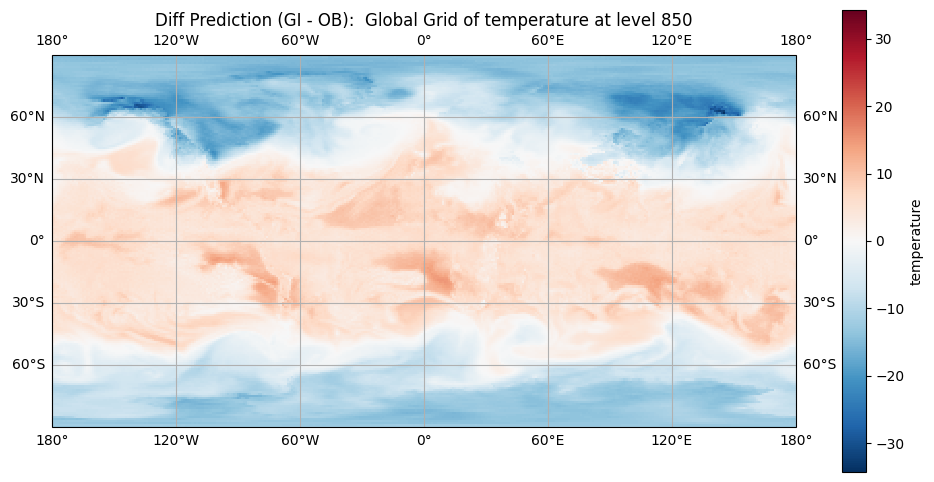

In [33]:
DIFF_temperature_var = GI_temperature_var - OB_temperature_var
data_var = DIFF_temperature_var

# If your longitude data ranges from 0 to 360 degrees, it often needs to be shifted
# to -180 to 180 for better plotting on a global map using cartopy.
# if data_var.lon.max() > 180:
#     # Shift the longitude values
#     ds['lon'] = (ds['lon'] + 180) % 360 - 180
#     ds = ds.sortby('lon')
#     data_var = ds[variable_name]
#     print("Longitude shifted to -180 to 180 range.")

# Select a single time slice or depth level if the data is 3D or 4D
if 'level' in data_var.dims:
    # Select the first time step for simplicity
    plot_data = data_var.isel(level=10)
    plot_title = f'Diff Prediction (GI - OB):  Global Grid of {variable_name} at level {plot_data.level.values}'
else:
# if 'time' in data_var.dims:
#     # Select the first time step for simplicity
#     plot_data = data_var.isel(time=0)
#     plot_title = f'Global Grid of {variable_name} at time {plot_data.time.values}'
# else:
    plot_data = data_var
    plot_title = f'New Obs-based Graphcast Prediction: Global Grid of {variable_name}'

# --- 3. Plotting the global grid ---

# Set up the figure and a map projection (e.g., PlateCarree is good for global rectangular grids)
fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

# Add coastlines and gridlines for context
#ax.add_feature(cfeature.COASTLINE, linestyle=':')
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
ax.set_global() # Ensure the map shows the whole globe

# Use xarray's built-in plot method, which intelligently uses matplotlib
# The transform argument tells cartopy that the data itself is in PlateCarree coordinates
#plot_data.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='viridis', cbar_kwargs={'label': f'{variable_name} ({data_var.units if hasattr(data_var, "units") else "units"})'})
plot_data.plot(ax=ax, transform=ccrs.PlateCarree())

# Add the title and display the plot in the notebook
plt.title(plot_title)
plt.show()
